findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


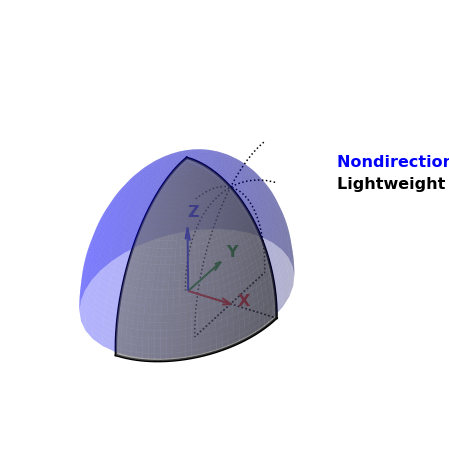

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 3D図の作成（図を左寄せし、ラベルを右側に配置）
fig = plt.figure(figsize=(12, 8))  # 横幅を広げる
ax = fig.add_subplot(111, projection='3d')

# フォント設定
font_settings = {'fontsize': 16, 'fontname': 'Arial', 'weight': 'bold'}

# 非指向性検出器（球体）の上半分を作成（半径6）
radius_inner = 6  # 検出器の半径
radius_outer = 6.2  # 遮蔽体の外側半径（厚さ0.2）
shift_x = -3  # 図全体を左に寄せるためのシフト

u = np.linspace(0, np.pi/2, 40)  # 上半分のみ
v = np.linspace(0, 2 * np.pi, 40)
u, v = np.meshgrid(u, v)

x_sphere = radius_inner * np.sin(u) * np.cos(v) + shift_x
y_sphere = radius_inner * np.sin(u) * np.sin(v)
z_sphere = radius_inner * np.cos(u)

# 非指向性検出器（青色）の上半分
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='blue', alpha=0.3, edgecolor='none')

# 遮蔽体（手前の1/4部分に移動）
theta = np.linspace(0, np.pi/2, 30)
phi = np.linspace(-np.pi/2, 0, 30)  # 遮蔽体を手前に配置（前方の1/4）
theta, phi = np.meshgrid(theta, phi)

x_outer = radius_outer * np.sin(theta) * np.cos(phi) + shift_x
y_outer = radius_outer * np.sin(theta) * np.sin(phi)
z_outer = radius_outer * np.cos(theta)

x_inner = radius_inner * np.sin(theta) * np.cos(phi) + shift_x
y_inner = radius_inner * np.sin(theta) * np.sin(phi)
z_inner = radius_inner * np.cos(theta)

# 遮蔽体の外側（半透明グレー、線なし）
ax.plot_surface(x_outer, y_outer, z_outer, color='gray', alpha=0.6, edgecolor='none')

# 遮蔽体の内側（半透明グレー、線なし）
ax.plot_surface(x_inner, y_inner, z_inner, color='gray', alpha=0.2, edgecolor='none')

# 遮蔽体の輪郭線（全て太くする）
ax.plot(x_outer[:, -1], y_outer[:, -1], z_outer[:, -1], color='black', linewidth=2.5)  # 縦の輪郭
ax.plot(x_outer[-1, :], y_outer[-1, :], z_outer[-1, :], color='black', linewidth=2.5)  # 横の輪郭
ax.plot(x_outer[:, 0], y_outer[:, 0], z_outer[:, 0], color='black', linewidth=2.5)  # 左側の輪郭
ax.plot(x_outer[0, :], y_outer[0, :], z_outer[0, :], color='black', linewidth=2.5)  # 上側の輪郭

# 1/4分割線（黒の点線）を修正
t = np.linspace(0, np.pi/2, 20)
x_line = radius_outer * np.sin(t) + shift_x
y_line = np.zeros_like(t)
z_line = radius_outer * np.cos(t)

# XZ平面の分割線
ax.plot(x_line, y_line, z_line, color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, x_line, z_line, color='black', linestyle='dotted', linewidth=1.5)

# XY平面の分割線
ax.plot(x_line, y_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, x_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)

# 遮蔽体がない部分にも線を追加（下半分）
ax.plot(-x_line, y_line, z_line, color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, -x_line, z_line, color='black', linestyle='dotted', linewidth=1.5)
ax.plot(-x_line, y_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, -x_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)

# XYZ軸の簡易表示（矢印とラベル）
ax.quiver(shift_x, 0, 0, 3, 0, 0, color='red', linewidth=2, arrow_length_ratio=0.2)
ax.text(shift_x + 3.5, 0, 0, "X", color="red", **font_settings)

ax.quiver(shift_x, 0, 0, 0, 3, 0, color='green', linewidth=2, arrow_length_ratio=0.2)
ax.text(shift_x, 3.5, 0, "Y", color="green", **font_settings)

ax.quiver(shift_x, 0, 0, 0, 0, 3, color='blue', linewidth=2, arrow_length_ratio=0.2)
ax.text(shift_x, 0, 3.5, "Z", color="blue", **font_settings)

# ラベルの追加（右側に配置）
ax.text(5, 3, 6, "Nondirectional Detector", color="blue", **font_settings, ha='left')
ax.text(5, 3, 5, "Lightweight Shield", color="black", **font_settings, ha='left')

# 座標軸と枠を完全に非表示
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_frame_on(False)
ax.axis('off')

# 図の表示範囲を調整（右のラベルが見切れないように拡大）
ax.set_xlim([-8, 8])
ax.set_ylim([-6, 6])
ax.set_zlim([0, 8])

# タイトル削除
ax.set_title("")

# 図の表示
plt.show()
